 ## Imports:

In [2]:
# Cell 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports done")

✅ Imports done


##  Load preprocessed splits:

In [3]:
# Cell 2 — Load splits from previous notebook output
# Upload train.csv, val.csv, test.csv to this notebook's input

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for f in filenames:
        print(os.path.join(dirname, f))

In [4]:
# Adjust paths based on Cell 2 output
train_df = pd.read_csv('/kaggle/input/datasets/sourabhsaxena/hatespeech01/train.csv')
val_df   = pd.read_csv('/kaggle/input/datasets/sourabhsaxena/hatespeech01/val.csv')
test_df  = pd.read_csv('/kaggle/input/datasets/sourabhsaxena/hatespeech01/test.csv')

# Combine train+val for final baseline training
# Why? We'll use cross-validation instead of a fixed val set for baseline
train_full = pd.concat([train_df, val_df], ignore_index=True)

print(f"Train+Val : {len(train_full)}")
print(f"Test      : {len(test_df)}")

X_train = train_full['text'].fillna('').astype(str)
y_train = train_full['label']

X_test  = test_df['text'].fillna('').astype(str)
y_test  = test_df['label']

print(f"\nTrain label dist:\n{y_train.value_counts()}")
print(f"\nTest label dist:\n{y_test.value_counts()}")

Train+Val : 23626
Test      : 5907

Train label dist:
label
0    12653
1    10973
Name: count, dtype: int64

Test label dist:
label
0    3164
1    2743
Name: count, dtype: int64


##  Build TF-IDF + LR Pipeline:

In [5]:
# Cell 3 — TF-IDF + Logistic Regression Pipeline

# Why Pipeline? 
# It chains preprocessing (TF-IDF) + model (LR) into one object.
# This means: fit on train only, transform test consistently.
# No data leakage possible.

lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        # Why these settings?
        ngram_range=(1, 2),     # Unigrams + bigrams: "hate speech" better than just "hate"
        max_features=50000,     # Top 50k features — enough for 29k samples
        min_df=2,               # Ignore terms appearing in <2 docs (typos, noise)
        max_df=0.95,            # Ignore terms in >95% docs (stopwords effectively)
        sublinear_tf=True,      # Apply log(tf) — reduces impact of very frequent terms
        analyzer='word',        # Word-level (vs char-level)
        strip_accents='unicode',
        token_pattern=r'\b\w+\b'  # Matches any word including Hinglish
    )),
    ('clf', LogisticRegression(
        C=1.0,              # Regularization strength (1.0 = balanced)
        max_iter=1000,      # Enough iterations to converge
        class_weight='balanced',  # Handles any remaining imbalance
        solver='lbfgs',     # Best for multiclass, good for binary too
        random_state=42
    ))
])

print("Pipeline:")
print(lr_pipeline)

Pipeline:
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=50000, min_df=2,
                                 ngram_range=(1, 2), strip_accents='unicode',
                                 sublinear_tf=True,
                                 token_pattern='\\b\\w+\\b')),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])


## Cross validation first:

In [6]:
# Cell 4 — Cross Validation
# Why CV before final fit?
# Gives more reliable estimate of generalization
# 5-fold = train on 80%, test on 20%, repeat 5 times

print("Running 5-fold Cross Validation...")
print("(This takes ~30 seconds)")

cv_scores = cross_val_score(
    lr_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='f1_macro',  # Macro F1 = average F1 across classes (unweighted)
    n_jobs=-1            # Use all CPU cores
)

print(f"\n5-Fold CV Macro-F1 Scores: {cv_scores.round(4)}")
print(f"Mean  : {cv_scores.mean():.4f}")
print(f"Std   : {cv_scores.std():.4f}")
print(f"95% CI: ({cv_scores.mean() - 2*cv_scores.std():.4f}, "
      f"{cv_scores.mean() + 2*cv_scores.std():.4f})")

Running 5-fold Cross Validation...
(This takes ~30 seconds)

5-Fold CV Macro-F1 Scores: [0.7039 0.7135 0.7175 0.7158 0.7179]
Mean  : 0.7137
Std   : 0.0052
95% CI: (0.7034, 0.7240)


## Train final model + evaluate:

In [7]:
# Cell 5 — Final Training + Evaluation

print("Training final model on full train+val set...")
lr_pipeline.fit(X_train, y_train)
print("✅ Training done!")

# Predictions
y_pred = lr_pipeline.predict(X_test)
y_prob = lr_pipeline.predict_proba(X_test)[:, 1]

# ── Core Metrics ───────────────────────────────────────────
print("\n" + "="*55)
print("BASELINE MODEL EVALUATION (Test Set)")
print("="*55)
print(classification_report(
    y_test, y_pred,
    target_names=['NOT (0)', 'HOF (1)'],
    digits=4
))

macro_f1  = f1_score(y_test, y_pred, average='macro')
roc_auc   = roc_auc_score(y_test, y_prob)

print(f"Macro F1  : {macro_f1:.4f}  ← PRIMARY METRIC")
print(f"ROC-AUC   : {roc_auc:.4f}")

Training final model on full train+val set...
✅ Training done!

BASELINE MODEL EVALUATION (Test Set)
              precision    recall  f1-score   support

     NOT (0)     0.7343    0.7339    0.7341      3164
     HOF (1)     0.6933    0.6938    0.6935      2743

    accuracy                         0.7153      5907
   macro avg     0.7138    0.7138    0.7138      5907
weighted avg     0.7153    0.7153    0.7153      5907

Macro F1  : 0.7138  ← PRIMARY METRIC
ROC-AUC   : 0.7933


##  Confusion matrix:

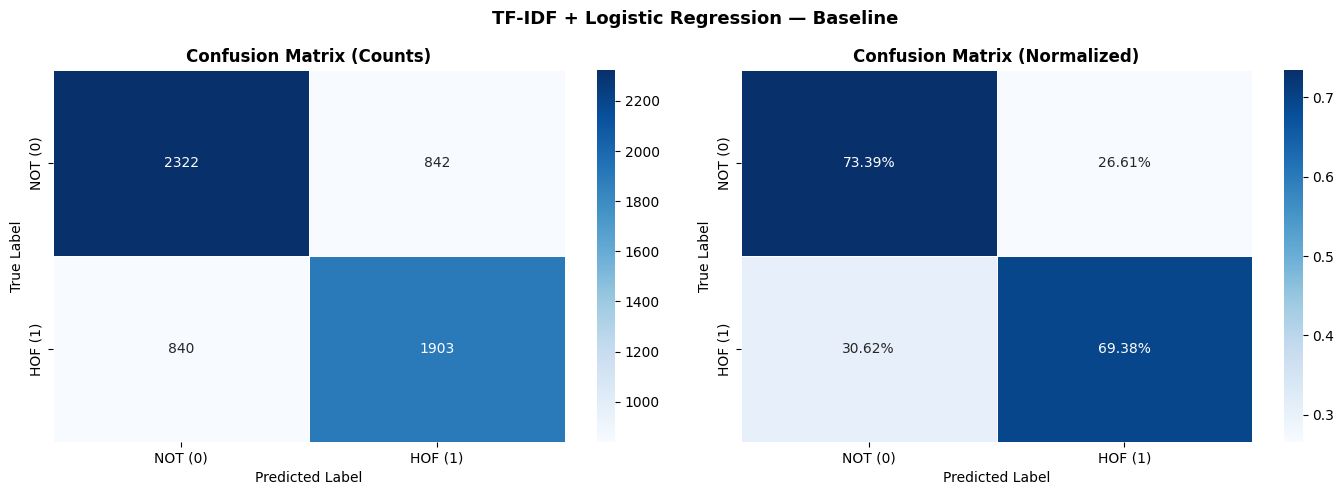


True  Negatives (correct NOT)  : 2322
False Positives (NOT→HOF wrong) : 842  ← Over-flagging
False Negatives (HOF→NOT wrong) : 840  ← Dangerous misses
True  Positives (correct HOF)   : 1903


In [8]:
# Cell 6 — Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['NOT (0)', 'HOF (1)'],
    yticklabels=['NOT (0)', 'HOF (1)'],
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Blues',
    xticklabels=['NOT (0)', 'HOF (1)'],
    yticklabels=['NOT (0)', 'HOF (1)'],
    ax=axes[1], linewidths=0.5
)
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.suptitle('TF-IDF + Logistic Regression — Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# What to look for:
# False Negatives (HOF predicted as NOT) = dangerous misses
# False Positives (NOT predicted as HOF) = over-flagging
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue  Negatives (correct NOT)  : {tn}")
print(f"False Positives (NOT→HOF wrong) : {fp}  ← Over-flagging")
print(f"False Negatives (HOF→NOT wrong) : {fn}  ← Dangerous misses")
print(f"True  Positives (correct HOF)   : {tp}")

## ROC Curve:

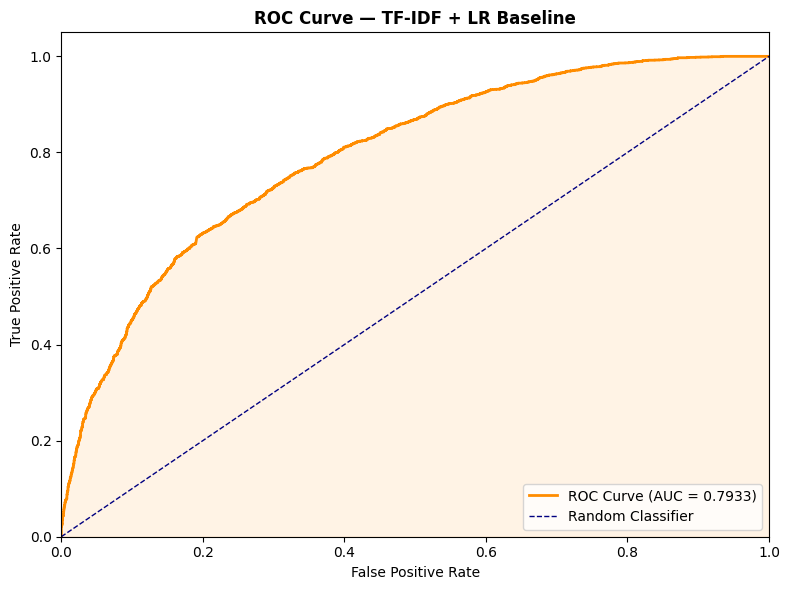

In [9]:
# Cell 7 — ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — TF-IDF + LR Baseline', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('baseline_roc_curve.png', dpi=150)
plt.show()

## Top predictive words

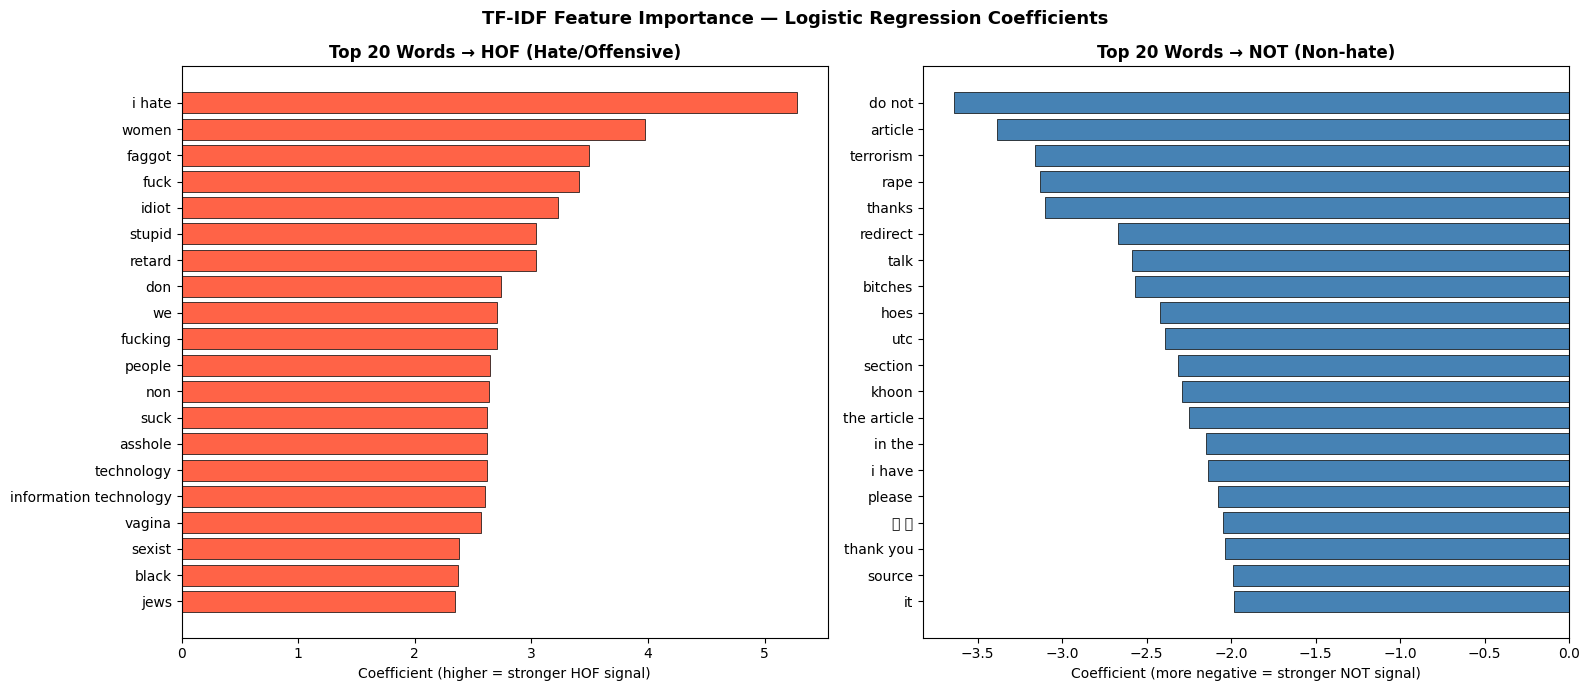

In [10]:
# Cell 8 — Most Important Features
# This is a KEY interview talking point — model interpretability

feature_names = lr_pipeline['tfidf'].get_feature_names_out()
coefficients  = lr_pipeline['clf'].coef_[0]

# Top features pushing toward HOF (hate)
top_hof_idx = np.argsort(coefficients)[-20:][::-1]
top_not_idx = np.argsort(coefficients)[:20]

top_hof_words = [(feature_names[i], coefficients[i]) for i in top_hof_idx]
top_not_words = [(feature_names[i], coefficients[i]) for i in top_not_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# HOF words
words_hof, coefs_hof = zip(*top_hof_words)
axes[0].barh(range(len(words_hof)), coefs_hof, color='tomato', edgecolor='black', linewidth=0.5)
axes[0].set_yticks(range(len(words_hof)))
axes[0].set_yticklabels(words_hof)
axes[0].set_title('Top 20 Words → HOF (Hate/Offensive)', fontweight='bold')
axes[0].set_xlabel('Coefficient (higher = stronger HOF signal)')
axes[0].invert_yaxis()

# NOT words
words_not, coefs_not = zip(*top_not_words)
axes[1].barh(range(len(words_not)), coefs_not, color='steelblue', edgecolor='black', linewidth=0.5)
axes[1].set_yticks(range(len(words_not)))
axes[1].set_yticklabels(words_not)
axes[1].set_title('Top 20 Words → NOT (Non-hate)', fontweight='bold')
axes[1].set_xlabel('Coefficient (more negative = stronger NOT signal)')
axes[1].invert_yaxis()

plt.suptitle('TF-IDF Feature Importance — Logistic Regression Coefficients',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## LinearSVC

In [11]:
# Cell 9 — LinearSVC Comparison
# SVM often outperforms LR on text classification

svc_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=50000,
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
    )),
    ('clf', LinearSVC(
        C=1.0,
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

svc_pipeline.fit(X_train, y_train)
y_pred_svc = svc_pipeline.predict(X_test)

svc_macro_f1 = f1_score(y_test, y_pred_svc, average='macro')

print("="*55)
print("LinearSVC EVALUATION (Test Set)")
print("="*55)
print(classification_report(
    y_test, y_pred_svc,
    target_names=['NOT (0)', 'HOF (1)'],
    digits=4
))
print(f"Macro F1: {svc_macro_f1:.4f}")

LinearSVC EVALUATION (Test Set)
              precision    recall  f1-score   support

     NOT (0)     0.7280    0.7206    0.7243      3164
     HOF (1)     0.6814    0.6894    0.6854      2743

    accuracy                         0.7061      5907
   macro avg     0.7047    0.7050    0.7048      5907
weighted avg     0.7064    0.7061    0.7062      5907

Macro F1: 0.7048


## Final comparison + save

In [12]:
# Cell 10 — Summary & Save

print("="*55)
print("📊 BASELINE RESULTS SUMMARY")
print("="*55)
print(f"Model                | Macro F1")
print(f"---------------------|----------")
print(f"TF-IDF + LR          | {macro_f1:.4f}")
print(f"TF-IDF + LinearSVC   | {svc_macro_f1:.4f}")
print(f"---------------------|----------")
print(f"Target (MuRIL goal)  | > 0.85")

# Save best model
import pickle

best_model = lr_pipeline if macro_f1 >= svc_macro_f1 else svc_pipeline
best_name  = 'LR' if macro_f1 >= svc_macro_f1 else 'SVC'
best_score = max(macro_f1, svc_macro_f1)

with open('/kaggle/working/baseline_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f"\n✅ Best baseline: TF-IDF + {best_name} (Macro F1: {best_score:.4f})")
print("✅ Saved → /kaggle/working/baseline_model.pkl")

# Save results for comparison later
results = {
    'model': f'TF-IDF + {best_name}',
    'macro_f1': best_score,
    'roc_auc': roc_auc if best_name == 'LR' else None,
    'test_samples': len(test_df)
}
pd.DataFrame([results]).to_csv('/kaggle/working/baseline_results.csv', index=False)
print("✅ Saved → /kaggle/working/baseline_results.csv")

📊 BASELINE RESULTS SUMMARY
Model                | Macro F1
---------------------|----------
TF-IDF + LR          | 0.7138
TF-IDF + LinearSVC   | 0.7048
---------------------|----------
Target (MuRIL goal)  | > 0.85

✅ Best baseline: TF-IDF + LR (Macro F1: 0.7138)
✅ Saved → /kaggle/working/baseline_model.pkl
✅ Saved → /kaggle/working/baseline_results.csv
